In [16]:
## 0. 환경설정

In [56]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Dense, Dropout, Conv2D, MaxPooling2D, Flatten, Reshape, SimpleRNN
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import confusion_matrix
from tensorflow.keras.datasets import mnist
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob

# 1. Autoencoder

## [이론] 오토인코더 (Autoencoder, AE) 핵심 정리

## 1. 오토인코더(Autoencoder)란?
오토인코더는 입력 데이터 자체를 레이블(정답)로 사용하여, 입력과 가장 유사한 출력을 복원하도록 학습하는 대표적인 비지도 학습(Unsupervised/Self-supervised Learning) 신경망입니다.

- **목표**: 입력 데이터 $X$를 받아, 중요한 특징만 압축한 뒤, 다시 원래 데이터와 거의 같은 $\hat{X}$를 복원하는 것 ($X \approx \hat{X}$)
- **핵심 가치**: 데이터의 효율적인 차원 축소(Dimensionality Reduction) 및 특징 추출(Feature Extraction)
- **PCA와의 차이**: PCA는 선형 변환만 가능한 차원 축소 기법이지만, 오토인코더는 비선형 활성화 함수를 사용해 더 복잡한 데이터 구조도 압축할 수 있습니다.

## 2. 오토인코더의 핵심 구조
오토인코더는 크게 세 가지 파트로 구성되어 있습니다.

### ① 인코더 (Encoder)
- 입력 데이터의 고차원 특징을 점진적으로 줄여나가는 고밀도 압축 과정입니다.
- 데이터의 본질적인 패턴(Feature)만 남기고 노이즈를 제거하는 필터 역할을 합니다.

### ② 잠재 공간 / 병목 구간 (Latent Space / Bottleneck)
- 인코더를 통해 최종적으로 압축된 핵심 정보 벡터(Latent Vector)가 머무는 공간입니다.
- 차원이 극도로 제한되어 있어(예: 실습 코드의 2차원 공간 `Dense(2)`), 모델이 가장 중요한 특징만 강제로 학습하게 만듭니다.
- 병목 차원이 입력보다 작은 구조를 **Undercomplete AE**라고 하며, 이것이 일반적인 형태입니다. 반대로 차원이 더 큰 **Overcomplete AE**는 별도의 제약(정규화, 노이즈 등) 없이는 단순히 입력을 그대로 복사(identity mapping)하는 문제가 생길 수 있습니다.

### ③ 디코더 (Decoder)
- 잠재 공간의 압축된 코드로부터 원래의 입력 이미지 크기로 정보를 복원(Reconstruction)하는 과정입니다.
- 실습에서 사용한 `UpSampling2D`나 `Resizing`을 통해 축소된 차원을 다시 확장하며 이미지를 선명하게 다듬습니다.
- 인코더와 대칭(mirror) 구조를 이루는 경우가 많습니다.

## 3. 오토인코더의 학습 원리: 손실 함수 (Loss Function)
오토인코더는 입력 값과 출력 값이 얼마나 똑같은지를 비교하며 학습합니다. 이를 복원 오차(Reconstruction Loss)라고 합니다.

- **Binary Crossentropy** (실습 코드 적용): 이미지의 각 픽셀 값을 0~1 사이의 확률값으로 보고, 입력 픽셀과 복원된 픽셀 사이의 유사도를 측정할 때 사용합니다. (출력층 activation에 `sigmoid` 사용 시 찰떡궁합)
- **MSE (Mean Squared Error)**: 입력 픽셀값과 출력 픽셀값의 평균 제곱 오차를 구하여 직접적인 수치 차이를 줄일 때 사용합니다.

## 4. 오토인코더의 주요 변형(Variants)
- **Denoising AE**: 입력에 일부러 노이즈를 추가한 뒤, 원본(노이즈 없는) 데이터를 복원하도록 학습 → 노이즈 제거 및 강건한 특징 학습에 사용
- **Sparse AE**: 잠재 벡터의 활성화 뉴런 수를 정규화(regularization)로 제한하여, 병목 차원이 커도 소수의 뉴런만 활성화되도록 강제
- **Convolutional AE**: Dense 레이어 대신 Conv2D/UpSampling2D를 사용해 이미지의 공간적 구조를 보존하며 압축·복원 (실습 코드와 관련)
- **VAE (Variational Autoencoder)**: 잠재 공간을 확률 분포(평균, 분산)로 학습시켜, 연속적이고 생성 가능한 잠재 공간을 만듦 → 새로운 데이터 생성(Generative)에 활용 가능
- **Stacked AE**: 여러 개의 오토인코더를 층층이 쌓아 깊은 특징 추출기를 구성

## 5. 활용 사례
- 이상 탐지(Anomaly Detection): 정상 데이터로만 학습 → 복원 오차가 큰 데이터를 이상치로 판단
- 이미지 노이즈 제거, 화질 개선
- 차원 축소를 통한 데이터 시각화(2~3차원 잠재 공간)
- 사전 학습(Pretraining)된 특징 추출기로 다른 모델에 전이(Transfer)
- 추천 시스템의 협업 필터링 보조

## 6. 한계
- 압축 과정에서 정보 손실이 불가피하여 완벽한 복원은 어려움
- 학습 데이터 분포에 과적합되기 쉬워, 학습 때 보지 못한 새로운 유형의 데이터에는 취약
- 일반 AE의 잠재 공간은 불연속적이라 임의의 지점에서 그럴듯한 새 데이터를 생성하기 어려움 (이 문제를 보완한 것이 VAE)

## 1. Mnist를 활용한 인코더와 디코더 실습

In [ ]:
# 실습 1-0 데이터 불러오기

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(x_train.shape, x_test.shape)

# 정규화 + 차원 추가 (흑백이라 채널 1)
x_train = x_train[:,:,:,np.newaxis] / 255
x_test = x_test[:,:,:,np.newaxis] / 255

# 라벨 원-핫 인코딩
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# 활용 함수
def learning_plot(hist):
    plt.figure(figsize=(12, 5))

    # 오차(Loss) 그래프
    plt.subplot(1, 2, 1)
    plt.plot(hist.history['loss'], label='train')
    plt.plot(hist.history['val_loss'], label='test')
    plt.legend(loc='best')
    plt.grid()
    plt.title('Loss')
    plt.xlabel('Epoch')

    # 정확도(Accuracy) 그래프
    plt.subplot(1, 2, 2)
    plt.plot(hist.history['accuracy'], label='train')
    plt.plot(hist.history['val_accuracy'], label='test')
    plt.legend(loc='best')
    plt.grid()
    plt.title('Accuracy')
    plt.xlabel('Epoch')

    plt.show()

print(x_train.shape, y_train.shape)

(60000, 28, 28) (10000, 28, 28)
(60000, 28, 28, 1) (60000, 10)


In [ ]:
# 실습 1-1 인코더
# 확보한 데이터를 통해 패턴을 만들고 특징을 모으는 과정

encoder = Sequential()
encoder.add(Input(shape=(28,28,1)))

# Conv2D (합성곱층): 이미지에 돋보기를 대고 훑으면서 선, 면, 굴곡 같은 특징(Feature)을 찾아내는 단계

encoder.add(Conv2D(filters=32,        # 이미지에서 32가지의 서로 다른 특징을 찾아내어 32장의 필터를 만듦
                   kernel_size=(5,5), # 특징을 포착하는 돋보기(필터)의 크기가 5x5
                   padding='same',    # 이미지가 필터를 거치면서 크기가 작아지는 것을 막기 위해 가장자리에 가상의 0을 채워줍니다
                   activation='relu'))

# MaxPooling2D(맥스 풀링층): 중요한 정보만 남기고 이미지 크기를 줄여(다운샘플링) 컴퓨터의 연산 부담을 줄입니다

encoder.add(MaxPooling2D(pool_size=(2,2))) #2x2 영역에서 가장 숫자가 큰(특징이 강한) 값 하나만 쏙 뽑아냅니다. 가로·세로가 반토막 나서 이미지 크기가 14x14로 줄어듭니다

encoder.add(Conv2D(filters=32, kernel_size=(5,5), padding='same', activation='relu'))
encoder.add(MaxPooling2D(pool_size=(2,2)))
encoder.add(Conv2D(filters=32, kernel_size=(5,5), padding='same', activation='relu'))
encoder.add(MaxPooling2D(pool_size=(2,2)))
encoder.add(Flatten()) # 3차원(가로 x 세로 x 채널)으로 쪼개져 있던 이미지 특징 데이터를 일반 신경망에 넣을 수 있도록 1차원 전선처럼 길게 한 줄로 펴주는 역할
encoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,096 (203.50 KB)

 Trainable params: 52,096 (203.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 실습 1-2 디코더
# 인코더로 모은 패턴으로 역으로 만들기

decoder = Sequential()
decoder.add(Input(shape=(288,)))
decoder.add(Dense(7*7*16))
decoder.add(Dense(14*14*16))
decoder.add(Dense(28*28, activation='sigmoid'))  # 최초 입력이 0~1이었으니까. 시그모이드
decoder.add(Reshape((28,28,1)))
decoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 784)            │       226,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │     2,461,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │     2,459,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,147,744 (19.64 MB)

 Trainable params: 5,147,744 (19.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 실습 1-3 인코더 + 디코더

encoder_input = Input(shape = (28,28,1))
encoder_output = encoder(encoder_input)
decoder_output = decoder(encoder_output)
autoencoder = Model(encoder_input, decoder_output)
autoencoder.summary()
autoencoder.compile(loss='binary_crossentropy', optimizer='adam')

# autoencoder.fit(x_train, x_train,                # 훈련 시 입력,출력값이 인코더와 디코더가 같아야함
#                 validation_data=(x_test,x_test), # 테스트 시 입력,출력값이 인코더와 디코더가 같아야함
#                 epochs=10)

In [ ]:
# 실습 1-4 모델 불러오기

ae = load_model("../Day_07/ae.keras")
ae.summary()

Model: "functional_138"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_24 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_13 (Sequential)      │ (None, 288)            │        52,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_22 (Sequential)      │ (None, 28, 28, 1)      │     5,147,744 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,599,522 (59.51 MB)

 Trainable params: 5,199,840 (19.84 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,399,682 (39.67 MB)

(1, 28, 28, 1)


In [ ]:
# 실습 1-5 테스트 자료 불러와서 모델 적용해보기
# 학습에 쓰인 mnist가 아닌 완전히 새로운 이미지를 넣어서 오토인코더가 얼마나 잘 복원하는지 확인

img_6 = Image.open('../Day_05/6.png')
img_cat = Image.open('../Day_06/Dogs_n_Cats/Cats/cat.0.jpg')

img6 = img_6.convert('L')  # 흑백(그레이스케일)로 변환 -> 모델이 채널 1(흑백)로 학습되어 있음
ndimg6 = 1-np.array(img6)[np.newaxis,:,:,np.newaxis] / 255
# /255 : 0~1로 정규화(학습 때와 동일하게)
# [np.newaxis, ...] : (28,28) -> (1,28,28,1) 배치차원+채널차원 추가 (모델은 항상 배치 단위 입력을 받음)
# 1 - : mnist는 배경이 검정(0)/글씨가 흰색(1)인데, 일반 사진은 반대라서 색을 반전시켜 맞춰줌
print(ndimg6.shape)
plt.imshow(ndimg6[0])
plt.show()
pred = ae.predict(ndimg6)   # 오토인코더 통과 -> 압축 후 복원된 이미지
plt.imshow(pred[0])
plt.show()

img = img_cat.convert('L')
img = img.resize((28,28))   # 모델 입력 크기(28x28)에 맞춰 리사이즈
ndimg = 1 - (np.array(img)[np.newaxis,:,:,np.newaxis] / 255)
print(ndimg.shape)
plt.imshow(ndimg[0])
plt.show()
pred = ae.predict(ndimg)
# 고양이 사진처럼 mnist 숫자와 전혀 다른 분포의 이미지는 복원이 잘 안 됨
# -> 오토인코더는 "학습한 데이터 분포"만 잘 압축/복원한다는 것을 보여주는 예시
plt.imshow(pred[0])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


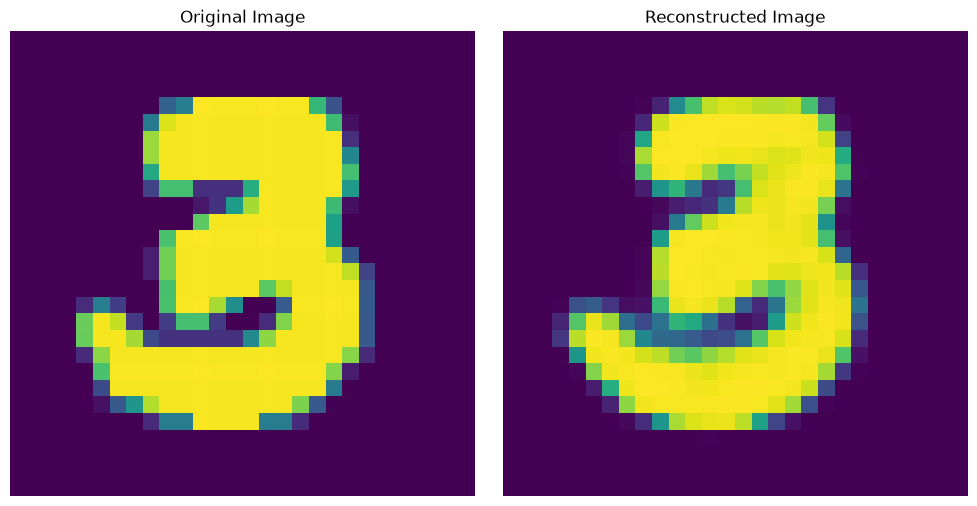

In [ ]:
# 실습 1-6 입출력 이미지 비교
# 인덱스값만 조절하면 비교됨

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(x_test[200])
axes[0].set_title('Original Image')
axes[0].axis('off')

pred = ae.predict(x_test[200:201])
axes[1].imshow(pred[0])
axes[1].set_title('Reconstructed Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# 실습 1-6 UpSampling 방식

from tensorflow.keras.layers import Reshape, UpSampling2D, Resizing

# 인코더 : 필터 수가 점점 줄어드는 과정
encoder = Sequential()
encoder.add(Input(shape=(28,28,1)))
encoder.add(Conv2D(filters=32, kernel_size=(5,5), padding='same', activation='relu'))
encoder.add(MaxPooling2D(pool_size=(2,2)))
encoder.add(Conv2D(filters=16, kernel_size=(5,5), padding='same', activation='relu'))
encoder.add(MaxPooling2D(pool_size=(2,2)))
encoder.add(Conv2D(filters=8, kernel_size=(5,5), padding='same', activation='relu'))
encoder.add(MaxPooling2D(pool_size=(2,2)))
encoder.add(Flatten())
encoder.add(Dense(2)) # 숫자를 2개로 축소시켜버림
encoder.summary()


# 디코더 : 공간 구조를 다시 살려가면서 복원(Upsampling)
decoder = Sequential()
decoder.add(Input(shape=(2,)))
decoder.add(Dense(72))
decoder.add(Reshape((3,3,8)))
decoder.add(UpSampling2D((2,2)))  # 풀링의 반대
decoder.add(Resizing(7,7))        # 사이즈 넓히는 과정에서 재조정

decoder.add(Conv2D(8, kernel_size=(5,5), padding='same', activation='relu'))
decoder.add(UpSampling2D((2,2)))
decoder.add(Conv2D(16, kernel_size=(5,5), padding='same', activation='relu'))
decoder.add(UpSampling2D((2,2)))
decoder.add(Conv2D(32, kernel_size=(5,5), padding='same', activation='relu'))
decoder.add(Dense(1, activation='sigmoid'))
decoder.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 16)     │        12,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 8)        │         3,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 72)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           146 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,002 (66.41 KB)

 Trainable params: 17,002 (66.41 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 72)             │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 3, 3, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 6, 6, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_2 (Resizing)           │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 7, 7, 8)        │         1,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 16)     │         3,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_8 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 28, 28, 1)      │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,905 (69.94 KB)

 Trainable params: 17,905 (69.94 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 실습 1-7 모델 학습

# encoder_input = Input(shape=(28,28,1))
# encoder_output = encoder(encoder_input)
# decoder_output = decoder(encoder_output)
# autoencoder = Model(encoder_input, decoder_output)
# autoencoder.summary()
# autoencoder.compile(loss='binary_crossentropy', optimizer='adam')
# autoencoder.fit(x_train, x_train, validation_data=(x_test, x_test),
#                 epochs=10)

Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 288)            │        52,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 28, 28, 1)      │        76,929 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,025 (504.00 KB)

 Trainable params: 129,025 (504.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 101s 51ms/step - loss: 0.1057 - val_loss: 0.0830
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 92s 49ms/step - loss: 0.0806 - val_loss: 0.0772
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 94s 50ms/step - loss: 0.0765 - val_loss: 0.0749
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 94s 50ms/step - loss: 0.0743 - val_loss: 0.0734
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 98s 52ms/step - loss: 0.0728 - val_loss: 0.0723
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 91s 48ms/step - loss: 0.0718 - val_loss: 0.0705
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 89s 48ms/step - loss: 0.0709 - val_loss: 0.0703
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 94s 50ms/step - loss: 0.0703 - val_loss: 0.0696
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 96s 51ms/step - loss: 0.0698 - val_loss: 0.0692
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 98s 52ms/step - loss: 0.0693 - val_loss: 0.0694


In [44]:
# 실습 1-8 학습 모델을 통한 검증
ae2 = load_model("../Day_07/ae2.keras")
ae2.summary()

Model: "functional_100"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_11 (Sequential)      │ (None, 2)              │        17,002 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_12 (Sequential)      │ (None, 28, 28, 1)      │        17,905 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,723 (409.08 KB)

 Trainable params: 34,907 (136.36 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 69,816 (272.72 KB)

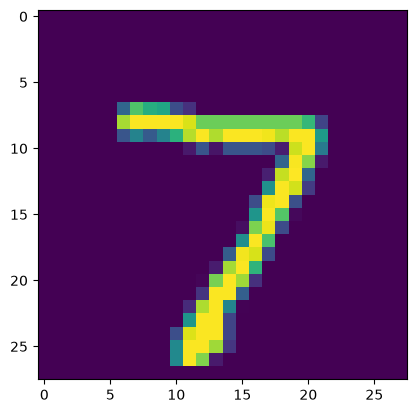

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 562ms/step


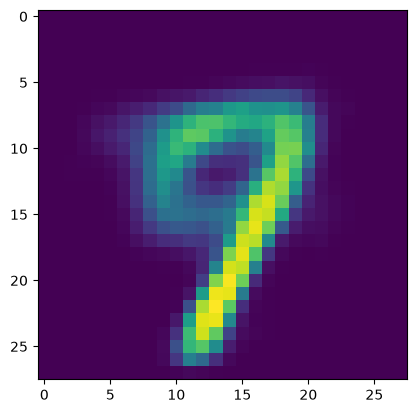

In [ ]:
# 실습 1-9 모델을 통한 예측 검증

plt.imshow(x_test[0])
plt.show()

pred = ae2.predict(x_test[:1])
plt.imshow(pred[0])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


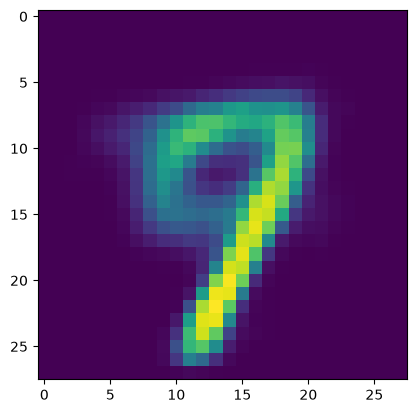

In [ ]:
# 1-10 예측 돌리기

# ae2 모델 : 내부적으로 encoder, decoder 두 개의 Sequential 모델을 합쳐놓은 것
# ae2.layers[0] = InputLayer, [1] = encoder, [2] = decoder
# -> 학습된 ae2에서 encoder/decoder를 각각 꺼내서 따로 쓸 수 있음
encoder = ae2.layers[1]
decoder = ae2.layers[2]

hv = encoder.predict(x_test[:1])   # 이미지(28,28,1) -> 2차원 잠재벡터(latent vector)로 압축
pred = decoder.predict(hv)         # 압축된 2차원 잠재벡터 -> 다시 이미지(28,28,1)로 복원

plt.imshow(pred[0])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


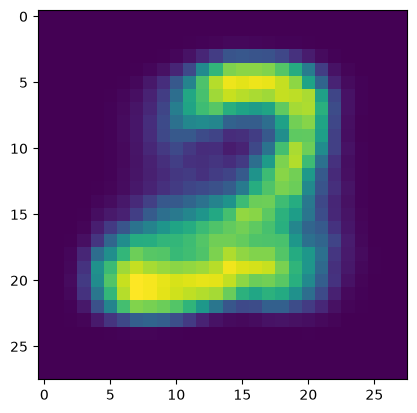

In [ ]:
# 1-11 좌표값 넣기

# encoder를 거치지 않고, 임의로 정한 2차원 좌표값을 바로 decoder에 넣어보는 실험
# 이 decoder의 latent 공간은 2차원이라 [x, y] 값 하나로 이미지를 "생성"할 수 있음
# -> 오토인코더의 decoder만 떼어내면 생성모델(generative model)처럼 쓸 수 있다는 것을 보여줌

pred = decoder.predict(np.array([[0.01, 0.01]]))
plt.imshow(pred[0])
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


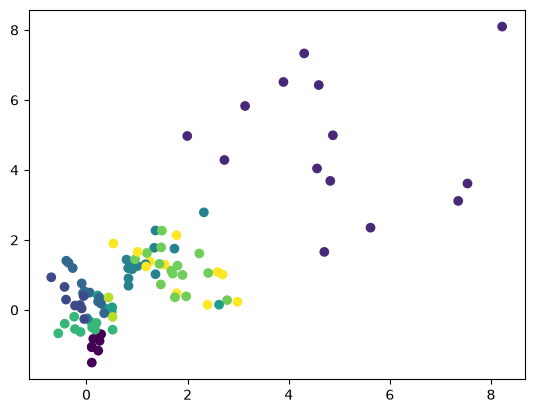

In [ ]:
# 실습 1-12 시각화

# 테스트 이미지 100장을 encoder에 통과시켜 각각 2차원 잠재좌표(x,y)로 변환

pred = encoder.predict(x_test[:100])

# 잠재공간(x,y) 위에 점을 찍고, 색은 실제 숫자 라벨(0~9)로 구분
# 같은 숫자끼리 잠재공간에서 얼마나 가깝게(군집을 이루며) 모여있는지 확인하는 시각화
# -> 오토인코더가 압축 과정에서 숫자별 특징을 잘 구분해서 학습했는지 보는 용도

plt.scatter(pred[:,0], pred[:,1], c=np.argmax(y_test[:100], axis=1))
plt.show()

# 2. RNN(Recurrent Neural Network)

## [이론] RNN (Recurrent Neural Network) 핵심 정리

## 1. RNN이란?
RNN(순환 신경망)은 시간의 흐름이나 순서(Sequence)가 있는 데이터를 처리하기 위해 고안된 인공신경망 구조입니다.

- **대상 데이터**: 텍스트(단어의 순서), 시계열 데이터(주가, 기상 정보), 음성 등 앞뒤 문맥이 중요한 데이터
- **핵심 특징**: 이전 시점($t-1$)에서 나온 출력(은닉 상태)이 다음 시점($t$)의 입력에 다시 영향을 주는 '순환(Loop) 구조'를 가집니다. 즉, 네트워크 내부에 '기억(Memory)'을 남길 수 있습니다.

## 2. RNN의 핵심 구조와 작동 원리

### ① 은닉 상태 (Hidden State, $h_t$)
RNN의 '기억 장치' 역할을 하는 가장 중요한 개념입니다.

- 현재 시점($t$)의 은닉 상태 $h_t$는 현재 입력값($x_t$)과 바로 이전 시점의 은닉 상태($h_{t-1}$)를 모두 고려하여 업데이트됩니다.
- **수식적 표현**: $h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h)$
  - $W_{xh}$: 입력값에 곱해지는 가중치
  - $W_{hh}$: 이전 기억(은닉 상태)에 곱해지는 가중치 (이 가중치가 모든 시점 $t$에서 공유된다는 것이 핵심!)

### ② 시간 펼치기 (Unfolding in Time)
- 순환하는 구조를 시간 축에 따라 오른쪽으로 길게 펼쳐놓으면, 결국 매우 깊은 층을 가진 일반 신경망(DNN)과 유사한 형태가 됩니다.
- 이 펼쳐진 구조를 통해 데이터가 순서대로 입력되면서 정보를 누적해 나갑니다.
- 이렇게 펼쳐진 구조 전체에 걸쳐 역전파를 수행하는 학습 방식을 **BPTT(Backpropagation Through Time)**라고 하며, 뒤에서 다룰 경사 소실/폭주 문제의 원인이 됩니다.

## 3. 입출력 형태에 따른 RNN 분류 (Architectures)
RNN은 풀고자 하는 문제에 따라 입출력의 형태를 매우 유연하게 설계할 수 있습니다.

| 분류 | 구조 (Input ➡️ Output) | 대표적인 활용 분야 |
|---|---|---|
| One-to-Many | 1개 입력 ➡️ 여러 개 출력 | 하나의 이미지를 보고 설명 문장을 생성하는 이미지 캡셔닝 |
| Many-to-One | 여러 개 입력 ➡️ 1개 출력 | 리뷰 텍스트를 분석하여 긍정/부정을 판단하는 감성 분석(Sentiment Analysis) |
| Many-to-Many (Symmetric) | 여러 개 입력 ➡️ 입력과 동일한 길이 출력 | 글자 단위로 다음 글자를 바로바로 맞추는 Character-level Language Model (실습 코드 구조) |
| Many-to-Many (Asymmetric) | 여러 개 입력 ➡️ 압축 후 번역문 출력 | 문장을 다 읽고 새로운 문장으로 번역하는 Seq2Seq 번역기 |

- 참고로 미래 시점 정보까지 참고해야 하는 문제(예: 문장 전체를 보고 품사 태깅)에는 정방향과 역방향을 동시에 학습하는 **Bidirectional RNN**이 사용되기도 합니다.

## 4. RNN의 치명적인 한계와 극복 (Evolution)
가장 기본형인 SimpleRNN은 한 시퀀스가 조금만 길어져도(보통 10~20단계 이상) 과거의 기억을 완전히 잃어버리는 치명적인 문제가 있습니다.

### 🚨 1) 경사 소실 문제 (Vanishing Gradient Problem) & 장기 의존성 (Long-Term Dependency) 문제
- 시간 축으로 길게 펼쳐진 RNN에서 BPTT를 진행할 때, 시간의 역방향으로 갈수록 미분값이 지속적으로 곱해지면서 기울기(Gradient)가 0에 수렴하게 됩니다.
- 결과적으로 문장 앞부분의 정보가 뒤쪽까지 전달되지 못하고 유실되는 현상이 발생합니다.
- 반대로 곱해지는 값이 1보다 크면 기울기가 기하급수적으로 커지는 **경사 폭주(Exploding Gradient)** 문제도 발생할 수 있으며, 이는 주로 **Gradient Clipping**(기울기 값을 일정 범위로 잘라내는 기법)으로 완화합니다.

### 💡 2) 해결사들의 등장: LSTM과 GRU
SimpleRNN의 문제를 해결하기 위해, 정보를 전달하거나 망각하는 '문(Gate)' 시스템을 도입한 고성능 RNN 변형 모델들이 등장했습니다.

- **LSTM (Long Short-Term Memory)**
  - Cell State(셀 상태)라는 일종의 고속도로를 뚫어 정보가 멀리까지 소실 없이 흘러가게 만듭니다.
  - Forget Gate, Input Gate, Output Gate 3개의 문을 사용하여 정보를 지우거나, 기억하거나, 내보내는 양을 정교하게 조절합니다.
- **GRU (Gated Recurrent Unit)**
  - LSTM의 성능은 유지하면서 구조를 단순화하여 계산 속도를 끌어올린 모델입니다.
  - 두 개의 문(Reset Gate, Update Gate)만 사용하며, Cell State와 Hidden State가 하나로 통합되어 있습니다.

### 참고: 모델 비교

| 구분 | SimpleRNN | LSTM | GRU |
|---|---|---|---|
| 게이트 수 | 없음 | 3개 (Forget/Input/Output) | 2개 (Reset/Update) |
| 장기 의존성 처리 | 취약 | 강함 | 강함 (LSTM과 유사) |
| 파라미터 수 / 연산량 | 적음 | 많음 | LSTM보다 적음 |
| 학습 속도 | 빠름 | 느림 | LSTM보다 빠름 |

- 참고로 최근에는 Transformer(Self-Attention 기반) 계열이 자연어처리 주류로 자리잡았지만, 스트리밍 처리나 경량 모델이 필요한 시계열/음성 도메인에서는 RNN 계열(특히 LSTM/GRU)이 여전히 활용됩니다.

## 1. Many-to-Many 모델

### 1. 데이터 준비

In [ ]:
# 실습 1-0 데이터 준비

txt = 'hihello'
set(txt)

{'e', 'h', 'i', 'l', 'o'}

In [ ]:
# 실습 1-1 딕셔너리 준비

char_set = sorted(set(txt))

ch2id = {c: i for i, c in enumerate(char_set)}
id2ch = {i: c for i, c in enumerate(char_set)}

print(ch2id)
print(id2ch)

# 텍스트를 숫자로 변환

txt_id = [ch2id[ch] for ch in txt]

print(txt_id)


{'e': 0, 'h': 1, 'i': 2, 'l': 3, 'o': 4}
{0: 'e', 1: 'h', 2: 'i', 3: 'l', 4: 'o'}
[1, 2, 1, 0, 3, 3, 4]


In [ ]:
# 실습 1-2 원핫 인코딩

data = to_categorical(txt_id)
print(data)

[[0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


In [ ]:
# 실습 1-3 데이터 분리

x_data = data[:-1][np.newaxis,:,:]
y_data = data[1:][np.newaxis,:,:]

print(x_data.shape, y_data.shape)

(1, 6, 5) (1, 6, 5)


### 2. 모델 설계

In [ ]:
# 2-1 모델 설계

model = Sequential()
model.add(Input(shape=(6,5)))                  # 입력 데이터의 형태(Timesteps, Features) // Timesteps : 한 번에 모델에 입력할 시퀀스의 길이 // Features : 각 시점마다 들어오는 단일 데이터의 특징 수(원핫 인코딩)
model.add(SimpleRNN(16,return_sequences=True)) # (은닉층 수, 입력된 모든 시점(1, 2, 3, 4, 5, 6번째 시점)마다의 출력값을 전부 다 반환)
model.add(Dense(5,activation='softmax'))       # 예측해야 할 클래스의 개수 / 출력값을 0~1 사이의 확률값으로 설정
model.summary()

model.compile(loss='categorical_crossentropy', optimizer='adam',metrics=['accuracy'])
model.fit(x_data, y_data, epochs=100)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 6, 16)          │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6, 5)           │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 437 (1.71 KB)

 Trainable params: 437 (1.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3333 - loss: 1.5487
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.5000 - loss: 1.5355
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.5000 - loss: 1.5225
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.5000 - loss: 1.5094
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5000 - loss: 1.4965
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.5000 - loss: 1.4836
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5000 - loss: 1.4708
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.5000 - loss: 1.4580
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.5000 - loss: 1.4454
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.5000 - loss: 1.4328
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.5000 - loss: 1.4203
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.

In [ ]:
# 실습 2-2 예측

pred = model.predict(x_data)

print([id2ch[id] for id in np.argmax(pred[0], axis = 1)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
['i', 'h', 'e', 'l', 'l', 'o']


## 2. Many-to-One 모델

### 1. 데이터 준비

In [ ]:
# 실습 1-0 문장 단위 감성 분류 실습
# 정수 인덱스 매핑

docs = ['i love you', 'i hate you', 'i like you', 'i curse you']

wd2id = {}
id2wd = {}
idx=0

for sent in docs:
    for wd in sent.split():
        if wd2id.get(wd,-1) == -1: # 0부터 시작하니까. -1 로 시작
            wd2id[wd] = idx
            id2wd[idx] = wd
            idx += 1

print(wd2id)
print(id2wd)

{'i': 0, 'love': 1, 'you': 2, 'hate': 3, 'like': 4, 'curse': 5}
{0: 'i', 1: 'love', 2: 'you', 3: 'hate', 4: 'like', 5: 'curse'}


In [ ]:
# 실습 1-1  문장을 인덱스 시퀀스로 변환

data = []
for sent in docs :
    tmp=[]
    for wd in sent.split():
        tmp.append(wd2id[wd])
    data.append(tmp)
print(data)

[[0, 1, 2], [0, 3, 2], [0, 4, 2], [0, 5, 2]]


In [ ]:
# 실습 1-2 단어를 원-핫 인코딩. 
# shape (4, 3, 6) = (문장 4개, 단어 3개, 단어집합 크기 6)

x_data=to_categorical(data)

print(x_data)

[[[1. 0. 0. 0. 0. 0.]
  [0. 1. 0. 0. 0. 0.]
  [0. 0. 1. 0. 0. 0.]]

 [[1. 0. 0. 0. 0. 0.]
  [0. 0. 0. 1. 0. 0.]
  [0. 0. 1. 0. 0. 0.]]

 [[1. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 1. 0.]
  [0. 0. 1. 0. 0. 0.]]

 [[1. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 1.]
  [0. 0. 1. 0. 0. 0.]]]


In [ ]:
# 실습 1-3 라벨링 작업
# love,like가 들어간 문장은 긍정(1), hate,curse가 들어간 문장은 부정(0)으로 라벨링한 것

y_data = np.array([1,0,1,0])

### 2. 모델 설계

In [85]:
# 실습 2-0 모델 설계

model = Sequential()
model.add(Input(shape=(3, 6)))       # timesteps=3(단어 수) : 문장의 길이와 연관 / features=6(단어 집합 크기) : 단어의 수와 연관
model.add(SimpleRNN(16))             # return_sequences 안 씀 -> 마지막 시점 출력만 반환 (Many-to-One)
model.add(Dense(1, activation='sigmoid'))  # 이진 분류(긍정/부정) -> 출력 뉴런 1개, sigmoid
model.summary()

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_data, y_data, epochs=100)

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_9 (SimpleRNN)        │ (None, 16)             │           368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385 (1.50 KB)

 Trainable params: 385 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5000 - loss: 0.7547
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5000 - loss: 0.7434
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5000 - loss: 0.7324
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5000 - loss: 0.7217
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5000 - loss: 0.7112
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.5000 - loss: 0.7011
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5000 - loss: 0.6913
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5000 - loss: 0.6817
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.5000 - loss: 0.6725
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5000 - loss: 0.6635
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5000 - loss: 0.6549
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5000 - lo

In [ ]:
# 실습 2-1 예측해보기

pred = model.predict(x_data)
print(pred)  # 1에 가까우면 긍정, 0에 가까우면 부정

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
[[0.89603287]
 [0.14299928]
 [0.63912463]
 [0.2999244 ]]


### 참고 : Many-to-Many 모델과 비교

SimpleRNN(16, return_sequences=True) → SimpleRNN(16) (시퀀스 전체가 아니라 마지막 값만 필요)

Dense(5, activation='softmax') → Dense(1, activation='sigmoid') (5개 문자 중 하나가 아니라 긍정/부정 이진 분류)

loss categorical_crossentropy → binary_crossentropy

## 3. Mnist를 활용한 실습

In [87]:
# 실습 3-0 데이터 불러오기

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(x_train.shape, x_test.shape)

(60000, 28, 28) (10000, 28, 28)


In [88]:
# 실습 3-1 데이터 전처리

# 정규화만 수행 (RNN은 채널 차원 불필요 -> (28,28)을 그대로 timesteps x features로 사용)
x_train_nm = x_train / 255
x_test_nm = x_test / 255

# 라벨 원-핫 인코딩
y_train_oh = to_categorical(y_train)
y_test_oh = to_categorical(y_test)

print(x_train_nm.shape, y_train_oh.shape)

(60000, 28, 28) (60000, 10)


In [89]:
# 실습 3-2 모델 설계

model = Sequential()
model.add(Input(shape=(28, 28)))                # timesteps=28, features=28
model.add(SimpleRNN(64, return_sequences=True)) # 출력값 전부 전달
model.add(SimpleRNN(64))                        # return_sequences 없음 -> 마지막 시점 출력만 사용 (Many-to-One)
model.add(Dense(10, activation='softmax'))      # 0~9 숫자, 다중분류
model.summary()

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train_nm, y_train_oh, validation_data=(x_test_nm, y_test_oh), epochs=5)

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_10 (SimpleRNN)       │ (None, 28, 64)         │         5,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_11 (SimpleRNN)       │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,858 (58.04 KB)

 Trainable params: 14,858 (58.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - accuracy: 0.8730 - loss: 0.4097 - val_accuracy: 0.9331 - val_loss: 0.2308
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9409 - loss: 0.2037 - val_accuracy: 0.9482 - val_loss: 0.1735
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9506 - loss: 0.1704 - val_accuracy: 0.9526 - val_loss: 0.1702
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9549 - loss: 0.1562 - val_accuracy: 0.9585 - val_loss: 0.1440
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - accuracy: 0.9574 - loss: 0.1494 - val_accuracy: 0.9554 - val_loss: 0.1607


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
예측: 7


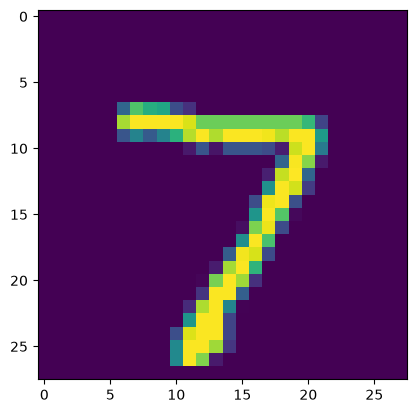

In [90]:
# 실습 3-3 예측 확인

pred = model.predict(x_test_nm[:1])
print('예측:', np.argmax(pred))

plt.imshow(x_test_nm[0])
plt.show()